In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/santhraul/boom-bike-dataset/bike_sharing_data.csv
/kaggle/input/datasets/santhraul/boom-bike-dataset/Readme.txt


In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np

In [ ]:
import os

# Find exact path of your file
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/santhraul/boom-bike-dataset/bike_sharing_data.csv
/kaggle/input/datasets/santhraul/boom-bike-dataset/Readme.txt


In [ ]:
# Reading the dataset
dataset = pd.read_csv("/kaggle/input/datasets/santhraul/boom-bike-dataset/bike_sharing_data.csv")

In [ ]:
dataset.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [ ]:
dataset.shape

(730, 16)

In [ ]:
dataset.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [ ]:
dataset.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,365.500000,2.498630,0.500000,6.526027,0.028767,2.997260,0.683562,1.394521,20.319259,23.726322,62.765175,12.763620,849.249315,3658.757534,4508.006849
std,210.877136,1.110184,0.500343,3.450215,0.167266,2.006161,0.465405,0.544807,7.506729,8.150308,14.237589,5.195841,686.479875,1559.758728,1936.011647
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.424346,3.953480,0.000000,1.500244,2.000000,20.000000,22.000000
25%,183.250000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,13.811885,16.889713,52.000000,9.041650,316.250000,2502.250000,3169.750000
50%,365.500000,3.000000,0.500000,7.000000,0.000000,3.000000,1.000000,1.000000,20.465826,24.368225,62.625000,12.125325,717.000000,3664.500000,4548.500000
75%,547.750000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,26.880615,30.445775,72.989575,15.625589,1096.500000,4783.250000,5966.000000
max,730.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,35.328347,42.044800,97.250000,34.000021,3410.000000,6946.000000,8714.000000


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   dteday      730 non-null    object 
 2   season      730 non-null    int64  
 3   yr          730 non-null    int64  
 4   mnth        730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  hum         730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  cnt         730 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.4+ KB


In [ ]:
# Assigning string values to different seasons instead of numeric values

# 1 = Spring
dataset.loc[(dataset['season'] == 1), 'season'] = 'spring'

# 2 = Summer
dataset.loc[(dataset['season'] == 2), 'season'] = 'summer'

# 3 = fall
dataset.loc[(dataset['season'] == 3), 'season'] = 'fall'

# 4 = winter
dataset.loc[(dataset['season'] == 4), 'season'] = 'winter'

In [ ]:
dataset['season'].astype('category').value_counts()

season
fall      188
summer    184
spring    180
winter    178
Name: count, dtype: int64

In [ ]:
# 0 = 2018, 1 = 2019 : Year
dataset['yr'].astype('category').value_counts()

yr
0    365
1    365
Name: count, dtype: int64

In [ ]:
# Assigning string values to different months instead of numeric values
def object_map_mnths(x):
    return x.map({1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
                  7: 'Jul', 8: 'Aug', 9: 'Sept', 10: 'Oct', 11: 'Nov', 12: 'Dec'})

dataset[['mnth']] = dataset[['mnth']].apply(object_map_mnths)
dataset['mnth'].astype('category').value_counts()

mnth
Aug     62
Dec     62
Jul     62
Jan     62
Oct     62
May     62
Mar     62
Apr     60
Nov     60
Jun     60
Sept    60
Feb     56
Name: count, dtype: int64

In [ ]:
dataset['holiday'].astype('category').value_counts()

holiday
0    709
1     21
Name: count, dtype: int64

In [ ]:
def str_map_weekday(x):
    return x.map({1: 'Mon', 2: 'Tues', 3: 'Wed', 4: 'Thurs', 5: 'Fri', 6: 'Sat', 0: 'Sun'})

dataset[['weekday']] = dataset[['weekday']].apply(str_map_weekday)
dataset['weekday'].astype('category').value_counts()

weekday
Mon      105
Sat      105
Sun      105
Fri      104
Thurs    104
Tues     104
Wed      103
Name: count, dtype: int64

In [ ]:
dataset['workingday'].astype('category').value_counts()

workingday
1    499
0    231
Name: count, dtype: int64

In [ ]:
# 1 = Clear, few clouds, Partly Cloudy
dataset.loc[(dataset['weathersit'] == 1), 'weathersit'] = 'A'

# 2 = Mist, Cloudy
dataset.loc[(dataset['weathersit'] == 2), 'weathersit'] = 'B'

# 3 = Light Snow, Heavy Rain
dataset.loc[(dataset['weathersit'] == 3), 'weathersit'] = 'C'

dataset['weathersit'].astype('category').value_counts()

weathersit
A    463
B    246
C     21
Name: count, dtype: int64

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


<Axes: xlabel='temp', ylabel='Density'>

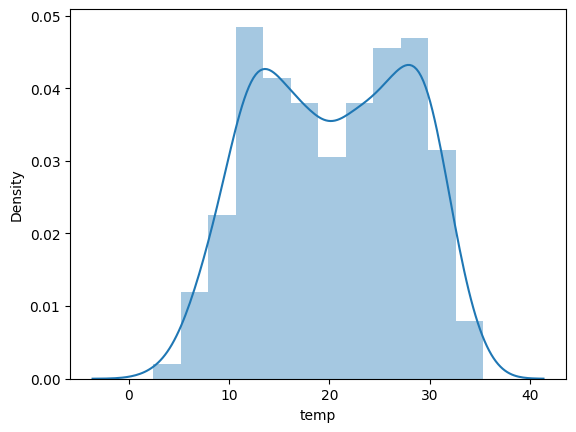

In [ ]:
sns.distplot(dataset['temp'])

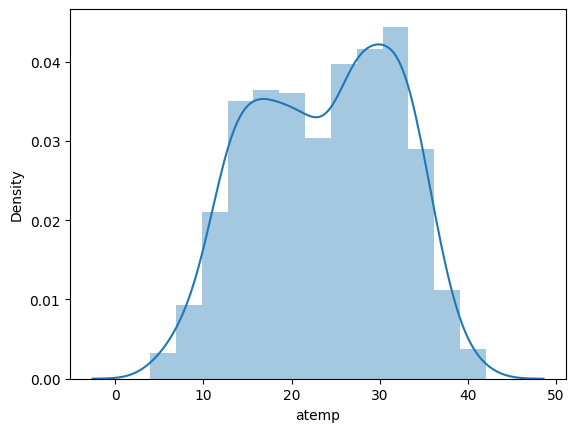

In [ ]:
sns.distplot(dataset['atemp'])
plt.show()

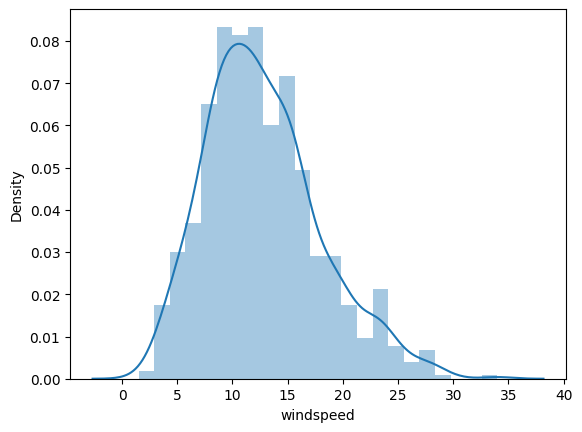

In [ ]:
sns.distplot(dataset['windspeed'])
plt.show()

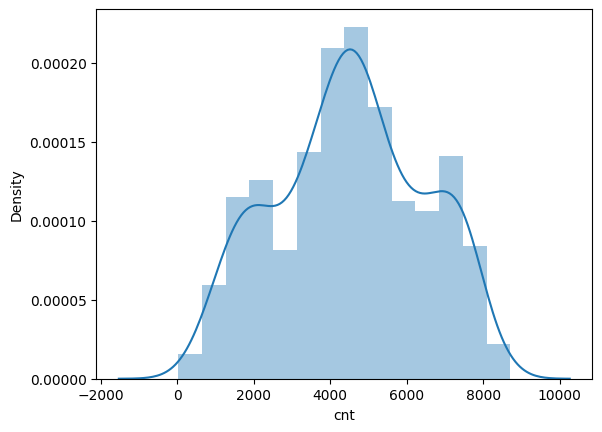

In [ ]:
sns.distplot(dataset['cnt'])
plt.show()

In [ ]:
dataset['dteday'] = dataset['dteday'].astype('datetime64[ns]')

In [ ]:
dataset_categorical = dataset.select_dtypes(exclude=['float64', 'datetime64', 'int64'])

In [ ]:
dataset_categorical.columns

Index(['season', 'mnth', 'weekday', 'weathersit'], dtype='object')

In [ ]:
dataset_categorical

,season,mnth,weekday,weathersit
0,spring,Jan,Sat,B
1,spring,Jan,Sun,B
2,spring,Jan,Mon,A
3,spring,Jan,Tues,A
4,spring,Jan,Wed,A
...,...,...,...,...
725,spring,Dec,Thurs,B
726,spring,Dec,Fri,B
727,spring,Dec,Sat,B
728,spring,Dec,Sun,A


In [ ]:
intVarList = ["casual", "registered", "cnt"]

for var in intVarList:
    dataset[var] = dataset[var].astype("float")

In [ ]:
dataset_numeric = dataset.select_dtypes(include=['float64'])
dataset_numeric.head()

,temp,atemp,hum,windspeed,casual,registered,cnt
0,14.110847,18.18125,80.5833,10.749882,331.0,654.0,985.0
1,14.902598,17.68695,69.6087,16.652113,131.0,670.0,801.0
2,8.050924,9.47025,43.7273,16.636703,120.0,1229.0,1349.0
3,8.200000,10.60610,59.0435,10.739832,108.0,1454.0,1562.0
4,9.305237,11.46350,43.6957,12.522300,82.0,1518.0,1600.0


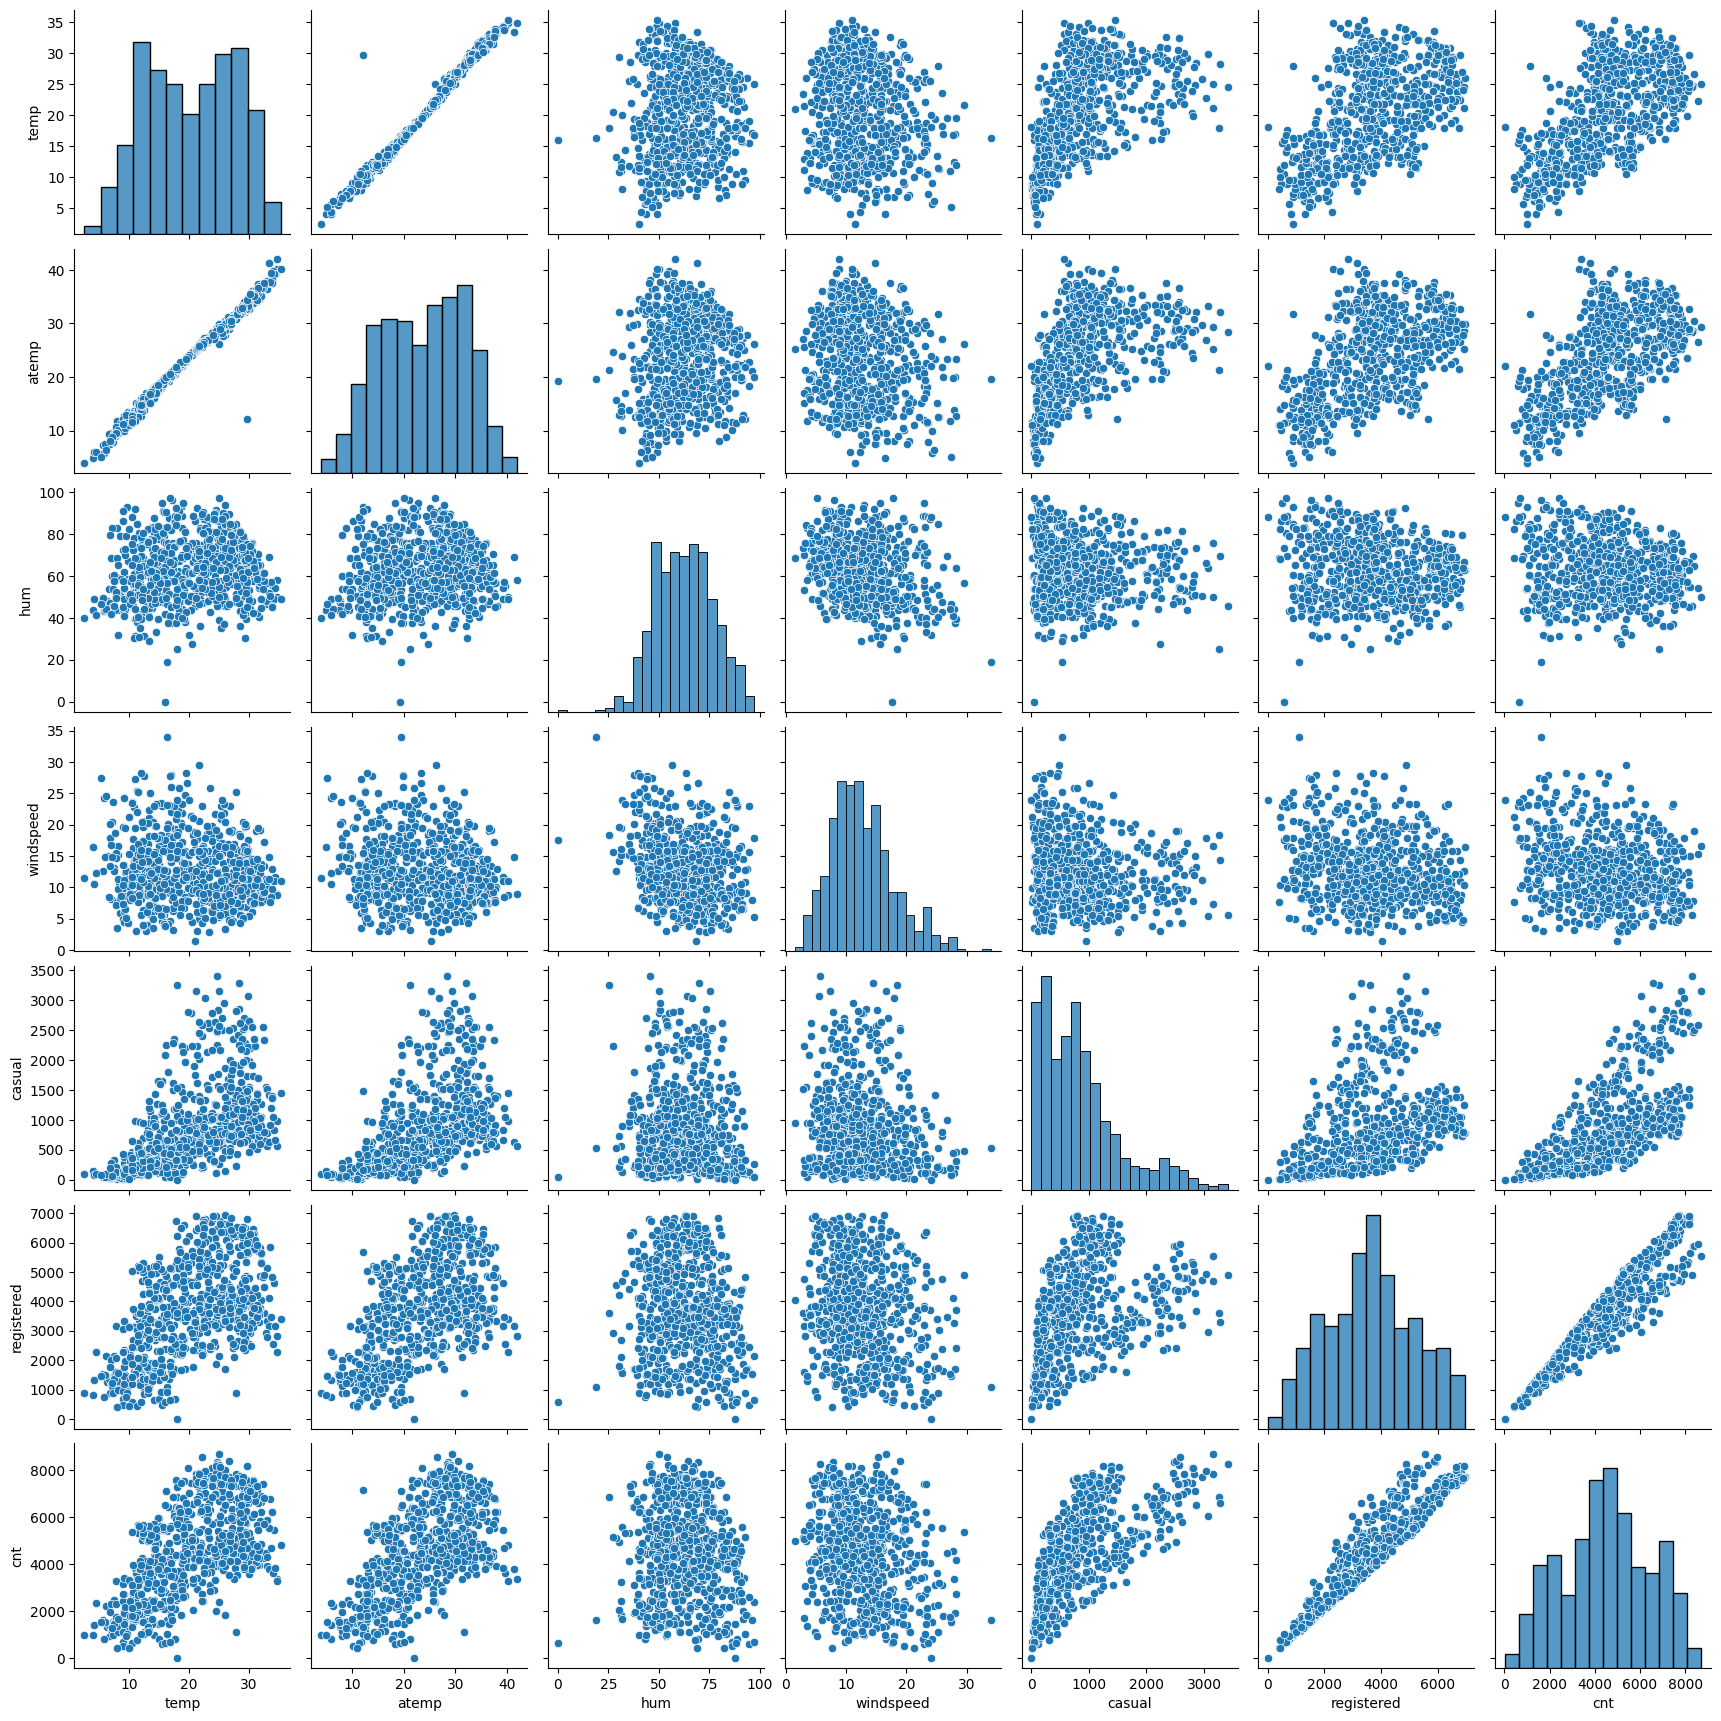

In [ ]:
sns.pairplot(dataset_numeric)
plt.show()

In [ ]:
cor = dataset_numeric.corr()
cor

,temp,atemp,hum,windspeed,casual,registered,cnt
temp,1.000000,0.991696,0.128565,-0.158186,0.542731,0.539436,0.627044
atemp,0.991696,1.000000,0.141512,-0.183876,0.543362,0.543678,0.630685
hum,0.128565,0.141512,1.000000,-0.248506,-0.075211,-0.089212,-0.098543
windspeed,-0.158186,-0.183876,-0.248506,1.000000,-0.167995,-0.217914,-0.235132
casual,0.542731,0.543362,-0.075211,-0.167995,1.000000,0.394137,0.672123
registered,0.539436,0.543678,-0.089212,-0.217914,0.394137,1.000000,0.945411
cnt,0.627044,0.630685,-0.098543,-0.235132,0.672123,0.945411,1.000000


<Axes: >

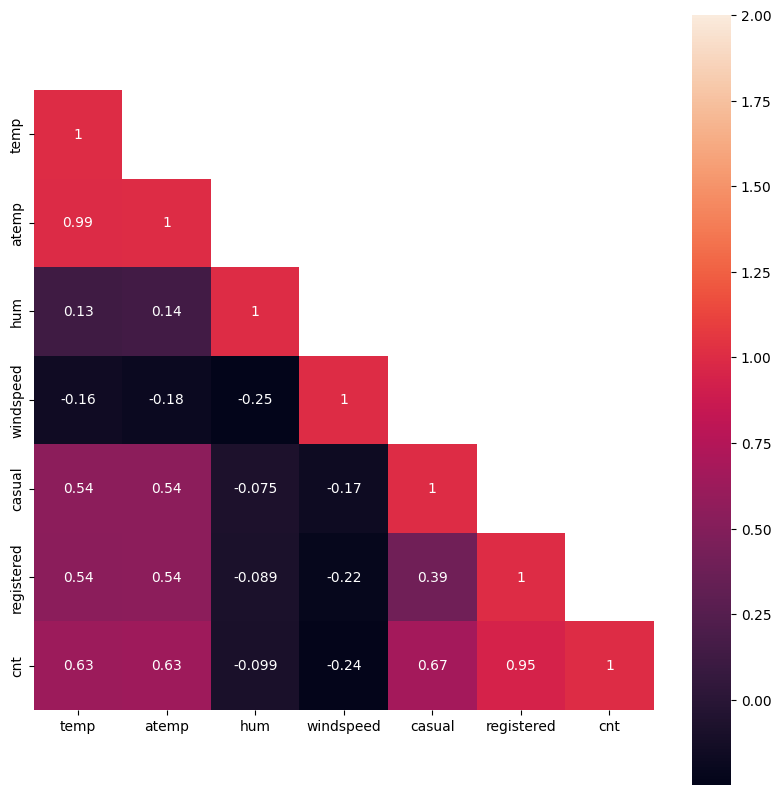

In [ ]:
mask = np.array(cor)
mask[np.tril_indices_from(mask)] = False
fig, ax = plt.subplots()
fig.set_size_inches(10, 10)
sns.heatmap(cor, mask=mask, vmax=2, square=True, annot=True)

<Axes: >

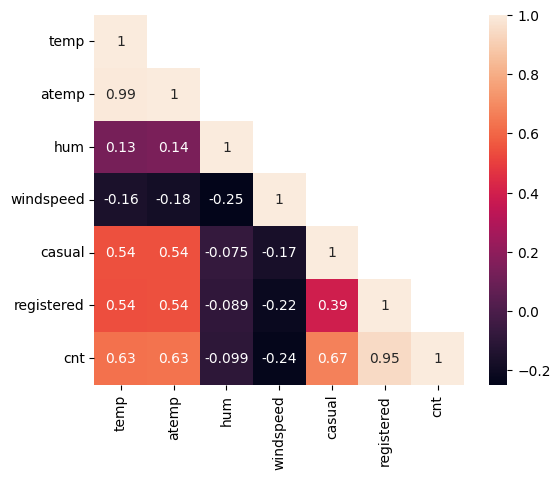

In [ ]:
sns.heatmap(cor, mask=mask, vmax=1, square=True, annot=True)

In [ ]:
dataset.drop('atemp', axis=1, inplace=True)

In [ ]:
dataset.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,casual,registered,cnt
0,1,2018-01-01,spring,0,Jan,0,Sat,0,B,14.110847,80.5833,10.749882,331.0,654.0,985.0
1,2,2018-02-01,spring,0,Jan,0,Sun,0,B,14.902598,69.6087,16.652113,131.0,670.0,801.0
2,3,2018-03-01,spring,0,Jan,0,Mon,1,A,8.050924,43.7273,16.636703,120.0,1229.0,1349.0
3,4,2018-04-01,spring,0,Jan,0,Tues,1,A,8.200000,59.0435,10.739832,108.0,1454.0,1562.0
4,5,2018-05-01,spring,0,Jan,0,Wed,1,A,9.305237,43.6957,12.522300,82.0,1518.0,1600.0


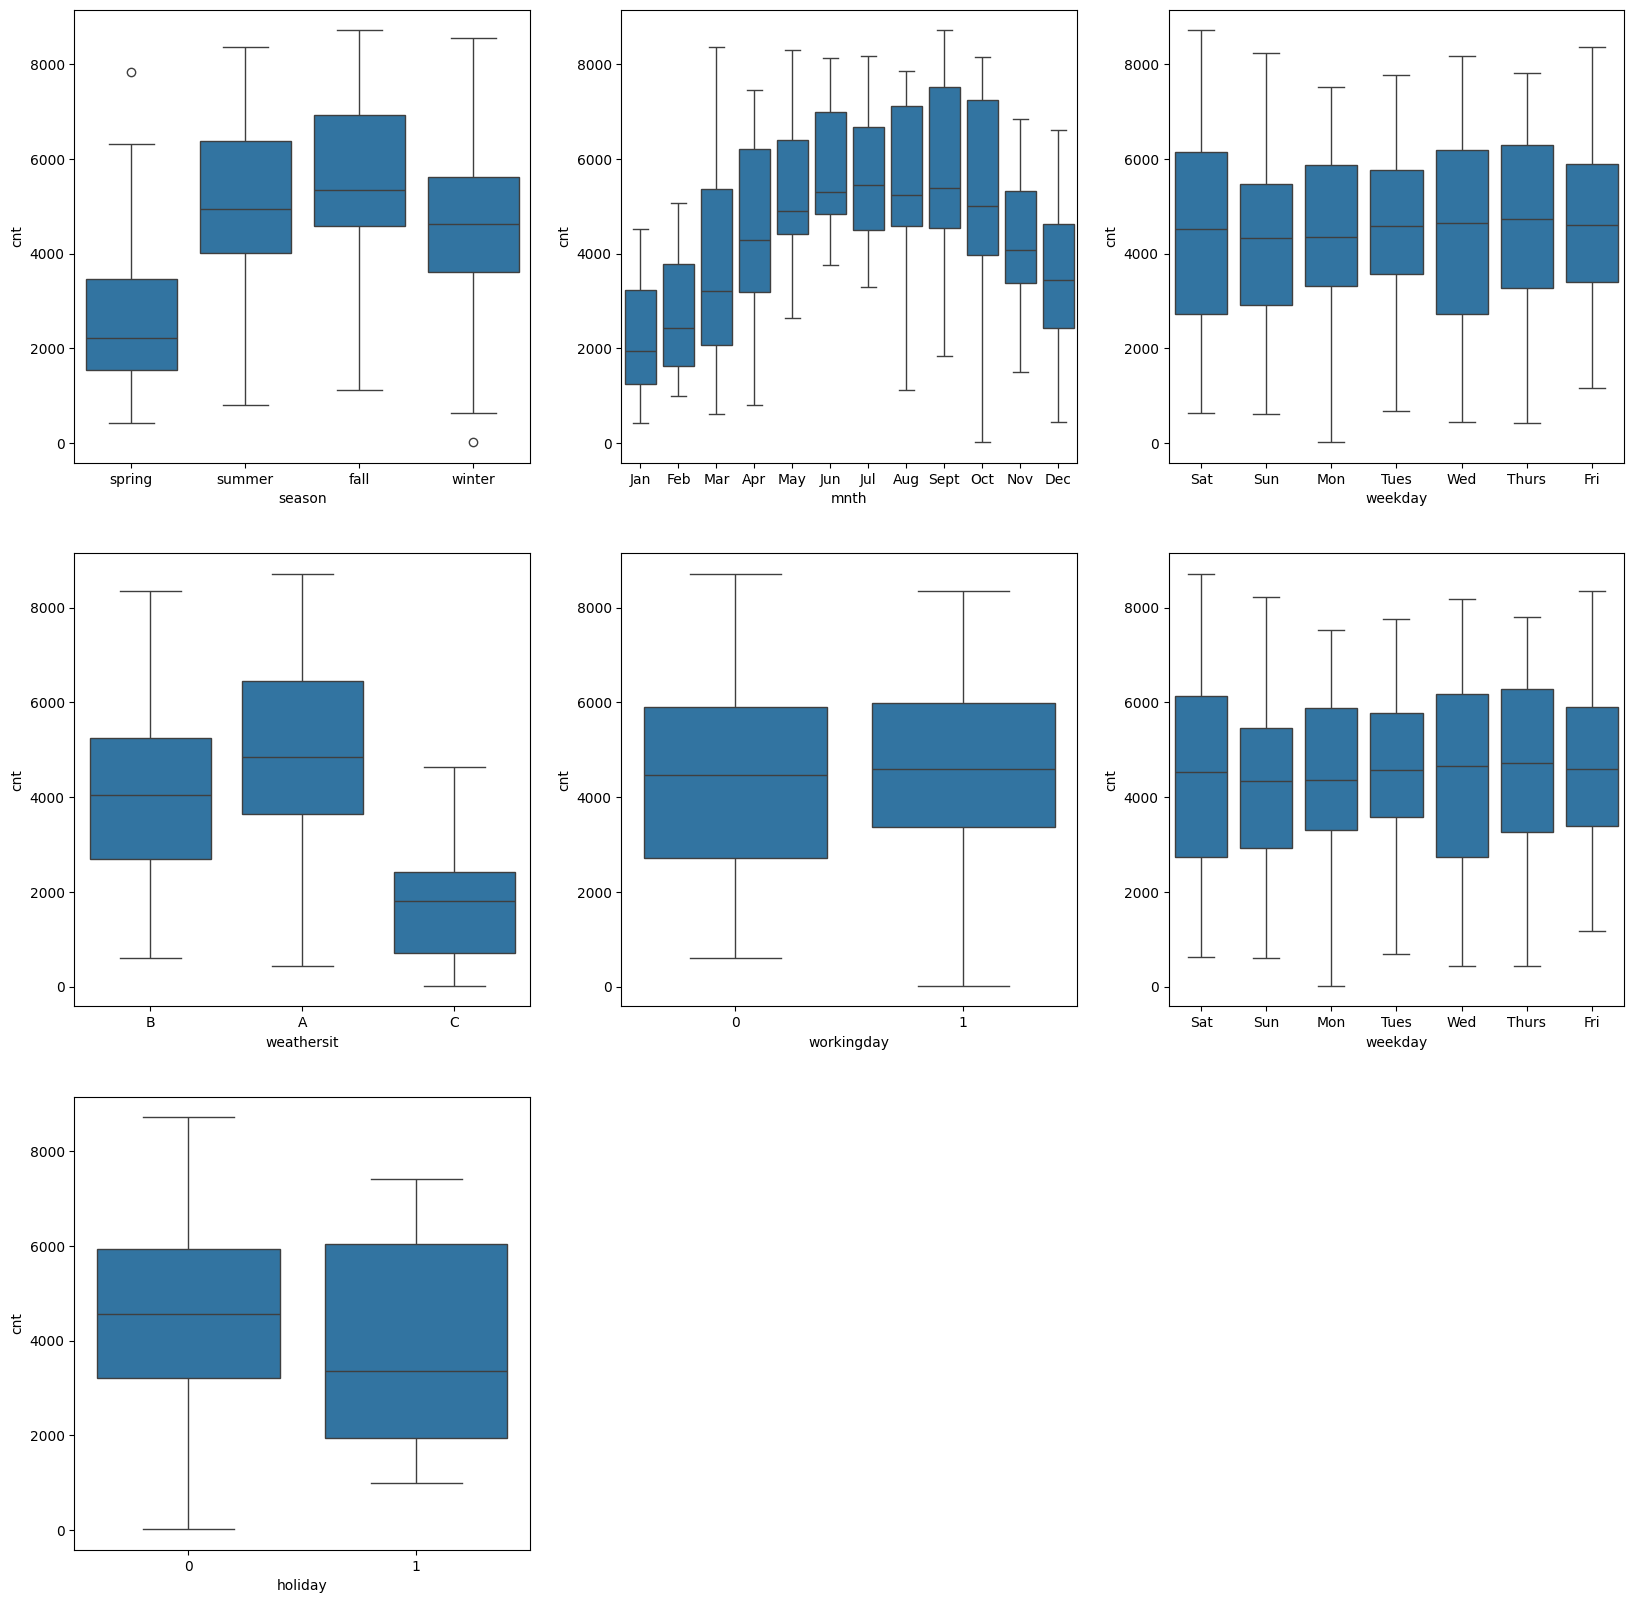

In [ ]:
plt.figure(figsize=(20,20))
plt.subplot(3,3,1)
sns.boxplot(x = 'season', y = 'cnt', data=dataset)
plt.subplot(3,3,2)
sns.boxplot(x = 'mnth', y = 'cnt', data=dataset)
plt.subplot(3,3,3)
sns.boxplot(x = 'weekday', y = 'cnt', data=dataset)
plt.subplot(3,3,4)
sns.boxplot(x = 'weathersit', y = 'cnt', data=dataset)
plt.subplot(3,3,5)
sns.boxplot(x = 'workingday', y = 'cnt', data=dataset)
plt.subplot(3,3,6)
sns.boxplot(x = 'weekday', y = 'cnt', data=dataset)
plt.subplot(3,3,7)
sns.boxplot(x = 'holiday', y = 'cnt', data=dataset)
plt.show()

In [ ]:
dataset_categorical = dataset.select_dtypes(include=['object'])

In [ ]:
dataset_categorical.head()

,season,mnth,weekday,weathersit
0,spring,Jan,Sat,B
1,spring,Jan,Sun,B
2,spring,Jan,Mon,A
3,spring,Jan,Tues,A
4,spring,Jan,Wed,A


In [ ]:
dataset_dummies = pd.get_dummies(dataset_categorical, drop_first=True)
dataset_dummies.head()

,season_spring,season_summer,season_winter,mnth_Aug,mnth_Dec,mnth_Feb,mnth_Jan,mnth_Jul,mnth_Jun,mnth_Mar,...,mnth_Oct,mnth_Sept,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thurs,weekday_Tues,weekday_Wed,weathersit_B,weathersit_C
0,True,False,False,False,False,False,True,False,False,False,...,False,False,False,True,False,False,False,False,True,False
1,True,False,False,False,False,False,True,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2,True,False,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,False,False,False
3,True,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,True,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [ ]:
# Drop Categorical variable columns
dataset = dataset.drop(list(dataset_categorical.columns), axis=1)
dataset

,instant,dteday,yr,holiday,workingday,temp,hum,windspeed,casual,registered,cnt
0,1,2018-01-01,0,0,0,14.110847,80.5833,10.749882,331.0,654.0,985.0
1,2,2018-02-01,0,0,0,14.902598,69.6087,16.652113,131.0,670.0,801.0
2,3,2018-03-01,0,0,1,8.050924,43.7273,16.636703,120.0,1229.0,1349.0
3,4,2018-04-01,0,0,1,8.200000,59.0435,10.739832,108.0,1454.0,1562.0
4,5,2018-05-01,0,0,1,9.305237,43.6957,12.522300,82.0,1518.0,1600.0
...,...,...,...,...,...,...,...,...,...,...,...
725,726,2019-12-27,1,0,1,10.420847,65.2917,23.458911,247.0,1867.0,2114.0
726,727,2019-12-28,1,0,1,10.386653,59.0000,10.416557,644.0,2451.0,3095.0
727,728,2019-12-29,1,0,0,10.386653,75.2917,8.333661,159.0,1182.0,1341.0
728,729,2019-12-30,1,0,0,10.489153,48.3333,23.500518,364.0,1432.0,1796.0


In [ ]:
# Concatenate dummy variables with the dataset
dataset = pd.concat([dataset, dataset_dummies], axis=1)

In [ ]:
dataset.head()

,instant,dteday,yr,holiday,workingday,temp,hum,windspeed,casual,registered,...,mnth_Oct,mnth_Sept,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thurs,weekday_Tues,weekday_Wed,weathersit_B,weathersit_C
0,1,2018-01-01,0,0,0,14.110847,80.5833,10.749882,331.0,654.0,...,False,False,False,True,False,False,False,False,True,False
1,2,2018-02-01,0,0,0,14.902598,69.6087,16.652113,131.0,670.0,...,False,False,False,False,True,False,False,False,True,False
2,3,2018-03-01,0,0,1,8.050924,43.7273,16.636703,120.0,1229.0,...,False,False,True,False,False,False,False,False,False,False
3,4,2018-04-01,0,0,1,8.200000,59.0435,10.739832,108.0,1454.0,...,False,False,False,False,False,False,True,False,False,False
4,5,2018-05-01,0,0,1,9.305237,43.6957,12.522300,82.0,1518.0,...,False,False,False,False,False,False,False,True,False,False


In [ ]:
dataset = dataset.drop(['instant', 'dteday'], axis=1, inplace=False)
dataset.head()

,yr,holiday,workingday,temp,hum,windspeed,casual,registered,cnt,season_spring,...,mnth_Oct,mnth_Sept,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thurs,weekday_Tues,weekday_Wed,weathersit_B,weathersit_C
0,0,0,0,14.110847,80.5833,10.749882,331.0,654.0,985.0,True,...,False,False,False,True,False,False,False,False,True,False
1,0,0,0,14.902598,69.6087,16.652113,131.0,670.0,801.0,True,...,False,False,False,False,True,False,False,False,True,False
2,0,0,1,8.050924,43.7273,16.636703,120.0,1229.0,1349.0,True,...,False,False,True,False,False,False,False,False,False,False
3,0,0,1,8.200000,59.0435,10.739832,108.0,1454.0,1562.0,True,...,False,False,False,False,False,False,True,False,False,False
4,0,0,1,9.305237,43.6957,12.522300,82.0,1518.0,1600.0,True,...,False,False,False,False,False,False,False,True,False,False


In [ ]:
from sklearn import linear_model
from sklearn.linear_model import LinearRegression


In [ ]:
from sklearn.model_selection import train_test_split
np.random.seed(0)
df_train, df_test = train_test_split(dataset, train_size = 0.7, test_size=0.3, random_state=100)

In [ ]:
df_train

,yr,holiday,workingday,temp,hum,windspeed,casual,registered,cnt,season_spring,...,mnth_Oct,mnth_Sept,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thurs,weekday_Tues,weekday_Wed,weathersit_B,weathersit_C
653,1,0,1,19.201653,55.8333,12.208807,922.0,6612.0,7534.0,False,...,True,False,False,False,False,False,True,False,False,False
576,1,0,1,29.246653,70.4167,11.083475,968.0,6248.0,7216.0,False,...,False,False,False,False,False,False,True,False,False,False
426,1,0,0,16.980847,62.1250,10.792293,956.0,3110.0,4066.0,True,...,False,False,False,True,False,False,False,False,True,False
728,1,0,0,10.489153,48.3333,23.500518,364.0,1432.0,1796.0,True,...,False,False,False,False,True,False,False,False,False,False
482,1,0,0,15.443347,48.9583,8.708325,1120.0,3100.0,4220.0,False,...,False,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
526,1,0,1,29.554153,58.7917,13.916771,1017.0,5647.0,6664.0,False,...,False,False,True,False,False,False,False,False,True,False
578,1,0,1,30.852500,65.9583,8.666718,983.0,6278.0,7261.0,False,...,False,False,False,False,False,True,False,False,False,False
53,0,0,1,9.091299,42.3043,6.305571,139.0,1778.0,1917.0,True,...,False,False,False,False,False,False,False,True,False,False
350,0,0,0,10.591653,56.0833,16.292189,275.0,2464.0,2739.0,False,...,False,False,False,True,False,False,False,False,True,False


In [ ]:

from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler()

In [ ]:
var = ["temp", "hum", "windspeed", "casual", "registered", "cnt"]

df_train[var] = scaler.fit_transform(df_train[var])

In [ ]:
df_train.describe()

,yr,holiday,workingday,temp,hum,windspeed,casual,registered,cnt
count,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000
mean,0.507843,0.025490,0.676471,0.537262,0.650369,0.320768,0.254661,0.523944,0.513620
std,0.500429,0.157763,0.468282,0.225844,0.145882,0.169797,0.206011,0.228175,0.224593
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.339853,0.538643,0.199179,0.094179,0.353487,0.356420
50%,1.000000,0.000000,1.000000,0.540519,0.653714,0.296763,0.212740,0.525123,0.518638
75%,1.000000,0.000000,1.000000,0.735215,0.754830,0.414447,0.327415,0.696073,0.684710
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


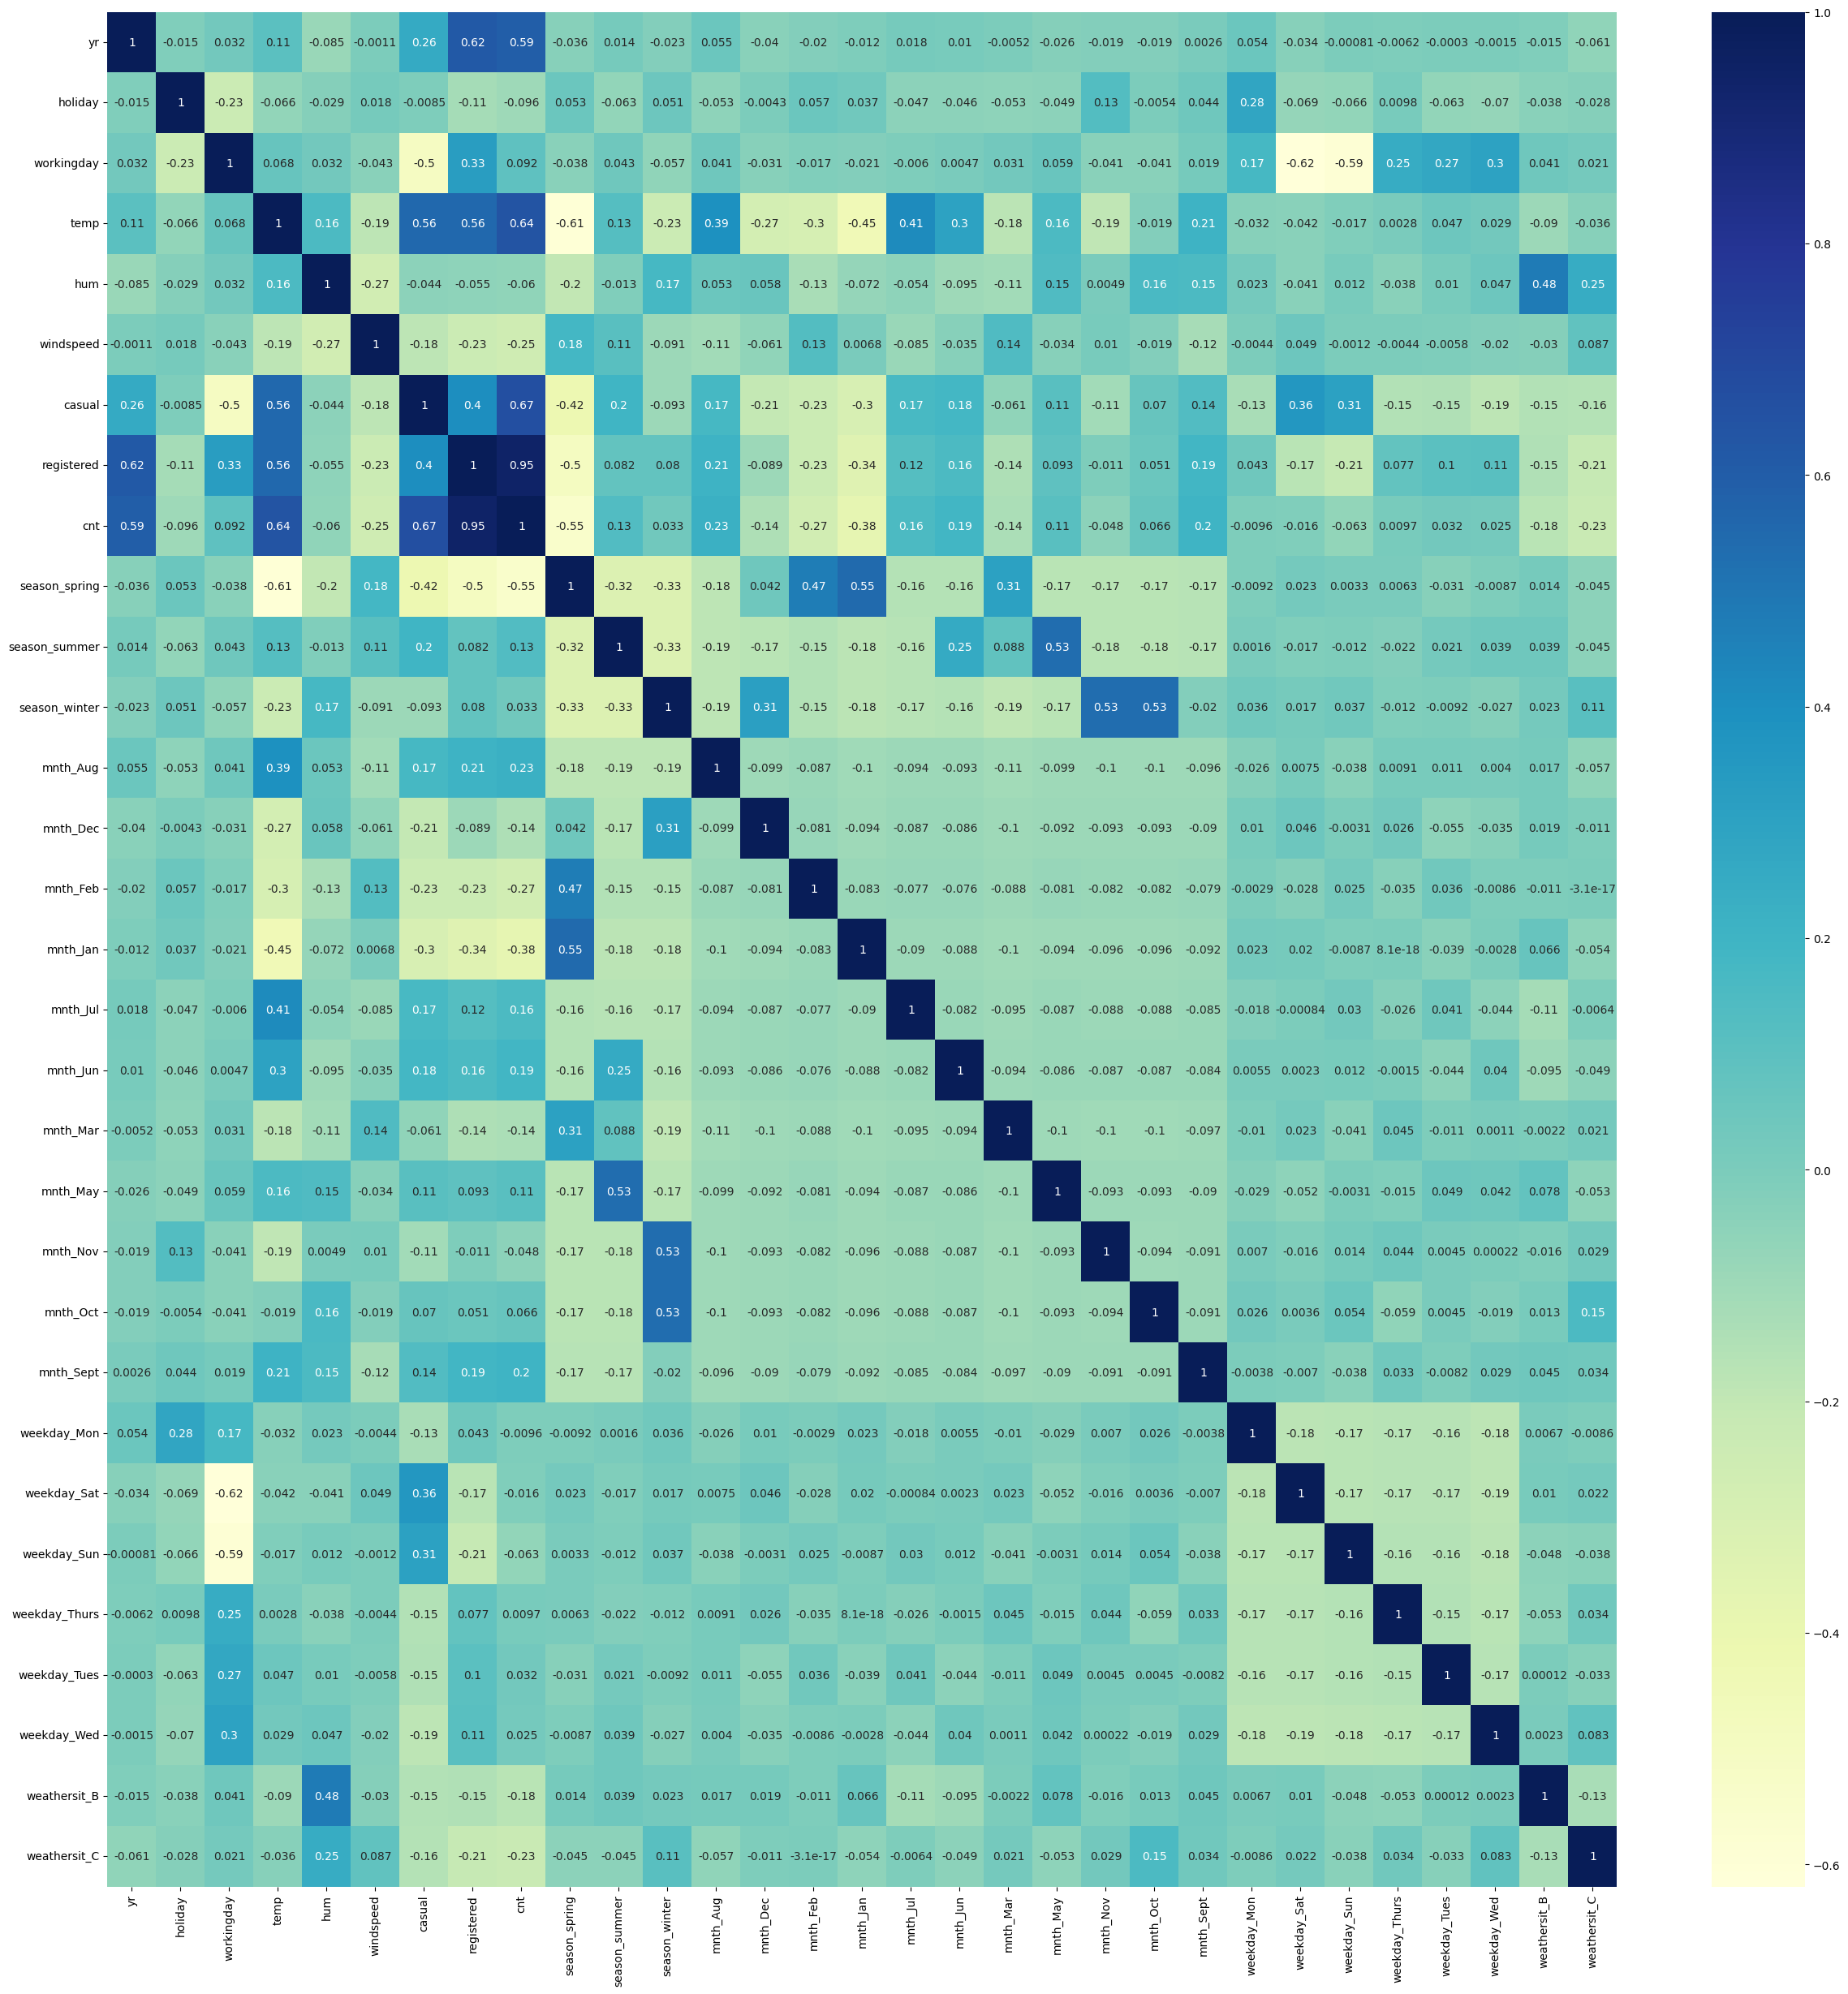

In [ ]:
plt.figure(figsize=(30,30))
sns.heatmap(df_train.corr(), annot=True, cmap="YlGnBu")
plt.show()

In [ ]:
x_train = df_train.drop(["casual", "registered"], axis=1)
y_train = df_train.pop('cnt')

In [ ]:
# Diving into X and y
y_train = df_train.iloc[:, -1]  # Get the last column (cnt)
x_train = df_train.drop(["casual", "registered"], axis=1)
x_train = x_train.iloc[:, :-1]  # Drop the last column

In [ ]:
x_train.head()

,yr,holiday,workingday,temp,hum,windspeed,season_spring,season_summer,season_winter,mnth_Aug,...,mnth_Nov,mnth_Oct,mnth_Sept,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thurs,weekday_Tues,weekday_Wed,weathersit_B
653,1,0,1,0.509887,0.575354,0.300794,False,False,True,False,...,False,True,False,False,False,False,False,True,False,False
576,1,0,1,0.815169,0.725633,0.264686,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
426,1,0,0,0.442393,0.640189,0.255342,True,False,False,False,...,False,False,False,False,True,False,False,False,False,True
728,1,0,0,0.245101,0.498067,0.663106,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
482,1,0,0,0.395666,0.504508,0.188475,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True


In [ ]:
np.array(df_train)

array([[1, 0, 1, ..., False, False, False],
       [1, 0, 1, ..., False, False, False],
       [1, 0, 0, ..., False, True, False],
       ...,
       [0, 0, 1, ..., True, False, False],
       [0, 0, 0, ..., False, True, False],
       [0, 0, 1, ..., False, True, False]], dtype=object)

In [ ]:
np.array(x_train)

array([[1, 0, 1, ..., True, False, False],
       [1, 0, 1, ..., True, False, False],
       [1, 0, 0, ..., False, False, True],
       ...,
       [0, 0, 1, ..., False, True, False],
       [0, 0, 0, ..., False, False, True],
       [0, 0, 1, ..., False, False, True]], dtype=object)

In [ ]:
# Diving into X and y
y_train = df_train.iloc[:, -1].astype(float)
x_train = df_train.drop(["casual", "registered"], axis=1)
x_train = x_train.iloc[:, :-1].astype(float)

In [ ]:
x_train.head()

,yr,holiday,workingday,temp,hum,windspeed,season_spring,season_summer,season_winter,mnth_Aug,...,mnth_Nov,mnth_Oct,mnth_Sept,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thurs,weekday_Tues,weekday_Wed,weathersit_B
653,1.0,0.0,1.0,0.509887,0.575354,0.300794,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
576,1.0,0.0,1.0,0.815169,0.725633,0.264686,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
426,1.0,0.0,0.0,0.442393,0.640189,0.255342,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
728,1.0,0.0,0.0,0.245101,0.498067,0.663106,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
482,1.0,0.0,0.0,0.395666,0.504508,0.188475,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
np.array(df_train)

array([[1, 0, 1, ..., False, False, False],
       [1, 0, 1, ..., False, False, False],
       [1, 0, 0, ..., False, True, False],
       ...,
       [0, 0, 1, ..., True, False, False],
       [0, 0, 0, ..., False, True, False],
       [0, 0, 1, ..., False, True, False]], dtype=object)

In [ ]:
np.array(x_train)

array([[1., 0., 1., ..., 1., 0., 0.],
       [1., 0., 1., ..., 1., 0., 0.],
       [1., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 1., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 1., ..., 0., 0., 1.]])

In [ ]:
import statsmodels.api as sm
x_train_lm = sm.add_constant(x_train)
lr = sm.OLS(y_train, x_train_lm).fit()

In [ ]:
lr.params

const           -0.155190
yr              -0.000510
holiday         -0.063862
workingday      -0.031120
temp            -0.238674
hum              0.581635
windspeed        0.180207
season_spring   -0.075462
season_summer   -0.052239
season_winter   -0.044710
mnth_Aug        -0.024788
mnth_Dec        -0.064813
mnth_Feb        -0.013449
mnth_Jan        -0.056663
mnth_Jul         0.020356
mnth_Jun         0.012814
mnth_Mar         0.002567
mnth_May        -0.028778
mnth_Nov        -0.034588
mnth_Oct         0.032026
mnth_Sept       -0.014450
weekday_Mon      0.004115
weekday_Sat     -0.009763
weekday_Sun     -0.050446
weekday_Thurs    0.028403
weekday_Tues    -0.004902
weekday_Wed      0.038299
weathersit_B    -0.129252
dtype: float64

In [ ]:
lm = LinearRegression()
lm.fit(x_train, y_train)

LinearRegression()

In [ ]:
print(lm.coef_)
print(lm.intercept_)

[-5.10496711e-04 -2.50646419e-02  7.67778712e-03 -2.38673527e-01
  5.81635457e-01  1.80206613e-01 -7.54618542e-02 -5.22393377e-02
 -4.47104004e-02 -2.47884509e-02 -6.48132986e-02 -1.34490800e-02
 -5.66629339e-02  2.03557909e-02  1.28142764e-02  2.56678968e-03
 -2.87778445e-02 -3.45881903e-02  3.20255712e-02 -1.44498415e-02
  4.11484859e-03  2.90348153e-02 -1.16479606e-02  2.84026017e-02
 -4.90226452e-03  3.82987393e-02 -1.29252261e-01]
-0.19398809580617435


In [ ]:
lr.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           weathersit_C   R-squared:                       0.226
Model:                            OLS   Adj. R-squared:                  0.184
Method:                 Least Squares   F-statistic:                     5.416
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           3.48e-15
Time:                        16:19:28   Log-Likelihood:                 248.42
No. Observations:                 510   AIC:                            -442.8
Df Residuals:                     483   BIC:                            -328.5
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.1552      0.060     -2.566      0.011      -0.274      -0.036
yr               -0.0005      0.014     -0.037      0.971      -0.028       0.027
holiday          -0.0639      0.041     -1.543      0.123      -0.145       0.017
workingday       -0.0311      0.021     -1.473      0.142      -0.073       0.010
temp             -0.2387      0.079     -3.012      0.003      -0.394      -0.083
hum               0.5816      0.061      9.535      0.000       0.462       0.701
windspeed         0.1802      0.044      4.129      0.000       0.094       0.266
season_spring    -0.0755      0.052     -1.460      0.145      -0.177       0.026
season_summer    -0.0522      0.045     -1.155      0.249      -0.141       0.037
season_winter    -0.0447      0.048     -0.928      0.354      -0.139       0.050
mnth_Aug         -0.0248      0.058     -0.426      0.670      -0.139       0.090
mnth_Dec         -0.0648      0.058     -1.118      0.264      -0.179       0.049
mnth_Feb         -0.0134      0.057     -0.237      0.813      -0.125       0.098
mnth_Jan         -0.0567      0.058     -0.979      0.328      -0.170       0.057
mnth_Jul          0.0204      0.061      0.336      0.737      -0.099       0.139
mnth_Jun          0.0128      0.043      0.296      0.768      -0.072       0.098
mnth_Mar          0.0026      0.042      0.061      0.952      -0.081       0.086
mnth_May         -0.0288      0.036     -0.793      0.428      -0.100       0.042
mnth_Nov         -0.0346      0.063     -0.551      0.582      -0.158       0.089
mnth_Oct          0.0320      0.062      0.518      0.605      -0.089       0.153
mnth_Sept        -0.0144      0.055     -0.261      0.794      -0.123       0.094
weekday_Mon       0.0041      0.026      0.156      0.876      -0.048       0.056
weekday_Sat      -0.0098      0.024     -0.412      0.681      -0.056       0.037
weekday_Sun      -0.0504      0.024     -2.106      0.036      -0.098      -0.003
weekday_Thurs     0.0284      0.027      1.061      0.289      -0.024       0.081
weekday_Tues     -0.0049      0.027     -0.183      0.855      -0.058       0.048
weekday_Wed       0.0383      0.026      1.492      0.136      -0.012       0.089
weathersit_B     -0.1293      0.017     -7.584      0.000      -0.163      -0.096
==============================================================================
Omnibus:                      475.484   Durbin-Watson:                   2.037
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            11905.905
Skew:                           4.203   Prob(JB):                         0.00
Kurtosis:                      25.127   Cond. No.                     7.08e+15
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of th

In [ ]:
print(df_train.columns.tolist())

['yr', 'holiday', 'workingday', 'temp', 'hum', 'windspeed', 'casual', 'registered', 'season_spring', 'season_summer', 'season_winter', 'mnth_Aug', 'mnth_Dec', 'mnth_Feb', 'mnth_Jan', 'mnth_Jul', 'mnth_Jun', 'mnth_Mar', 'mnth_May', 'mnth_Nov', 'mnth_Oct', 'mnth_Sept', 'weekday_Mon', 'weekday_Sat', 'weekday_Sun', 'weekday_Thurs', 'weekday_Tues', 'weekday_Wed', 'weathersit_B', 'weathersit_C']


In [ ]:
# cnt is already gone from df_train, y_train already exists from earlier pop()
x_train = df_train.drop(["casual", "registered"], axis=1)

In [ ]:
# Cell [75] - Fixed
x_train = df_train.drop(["casual", "registered"], axis=1)
# y_train already exists from earlier, no need to recreate it

In [ ]:
print(x_train.dtypes)
print("---")
print(y_train.dtype)

yr                 int64
holiday            int64
workingday         int64
temp             float64
hum              float64
windspeed        float64
season_spring       bool
season_summer       bool
season_winter       bool
mnth_Aug            bool
mnth_Dec            bool
mnth_Feb            bool
mnth_Jan            bool
mnth_Jul            bool
mnth_Jun            bool
mnth_Mar            bool
mnth_May            bool
mnth_Nov            bool
mnth_Oct            bool
mnth_Sept           bool
weekday_Mon         bool
weekday_Sat         bool
weekday_Sun         bool
weekday_Thurs       bool
weekday_Tues        bool
weekday_Wed         bool
weathersit_B        bool
weathersit_C        bool
dtype: object
---
float64


In [ ]:
x_train.head()

,yr,holiday,workingday,temp,hum,windspeed,season_spring,season_summer,season_winter,mnth_Aug,...,mnth_Oct,mnth_Sept,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thurs,weekday_Tues,weekday_Wed,weathersit_B,weathersit_C
653,1,0,1,0.509887,0.575354,0.300794,False,False,True,False,...,True,False,False,False,False,False,True,False,False,False
576,1,0,1,0.815169,0.725633,0.264686,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
426,1,0,0,0.442393,0.640189,0.255342,True,False,False,False,...,False,False,False,True,False,False,False,False,True,False
728,1,0,0,0.245101,0.498067,0.663106,True,False,False,False,...,False,False,False,False,True,False,False,False,False,False
482,1,0,0,0.395666,0.504508,0.188475,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False


In [ ]:
np.array(df_train)


array([[1, 0, 1, ..., False, False, False],
       [1, 0, 1, ..., False, False, False],
       [1, 0, 0, ..., False, True, False],
       ...,
       [0, 0, 1, ..., True, False, False],
       [0, 0, 0, ..., False, True, False],
       [0, 0, 1, ..., False, True, False]], dtype=object)

In [ ]:
np.array(x_train)

array([[1, 0, 1, ..., False, False, False],
       [1, 0, 1, ..., False, False, False],
       [1, 0, 0, ..., False, True, False],
       ...,
       [0, 0, 1, ..., True, False, False],
       [0, 0, 0, ..., False, True, False],
       [0, 0, 1, ..., False, True, False]], dtype=object)

In [ ]:
x_train = x_train.apply(pd.to_numeric, errors='coerce')
y_train = pd.to_numeric(y_train, errors='coerce')

# Drop any rows with NaN introduced by coercion
x_train = x_train.dropna()
y_train = y_train[x_train.index]

In [ ]:
x_train = x_train.apply(pd.to_numeric, errors='coerce')
y_train = pd.to_numeric(y_train, errors='coerce')

# Drop any rows with NaN introduced by coercion
x_train = x_train.dropna()
y_train = y_train[x_train.index]

In [ ]:
print(x_train.dtypes)
print("---")
print(y_train.dtype)

yr                 int64
holiday            int64
workingday         int64
temp             float64
hum              float64
windspeed        float64
season_spring       bool
season_summer       bool
season_winter       bool
mnth_Aug            bool
mnth_Dec            bool
mnth_Feb            bool
mnth_Jan            bool
mnth_Jul            bool
mnth_Jun            bool
mnth_Mar            bool
mnth_May            bool
mnth_Nov            bool
mnth_Oct            bool
mnth_Sept           bool
weekday_Mon         bool
weekday_Sat         bool
weekday_Sun         bool
weekday_Thurs       bool
weekday_Tues        bool
weekday_Wed         bool
weathersit_B        bool
weathersit_C        bool
dtype: object
---
float64


In [ ]:
x_train = x_train.apply(lambda x: x.astype(int) if x.dtype == bool else x)

In [ ]:
import statsmodels.api as sm
x_train_lm = sm.add_constant(x_train)
lr = sm.OLS(y_train, x_train_lm).fit()

In [ ]:
lr.params

const            7.480995e-16
yr              -7.632783e-17
holiday          1.457168e-16
workingday       2.272488e-16
temp            -4.857226e-16
hum             -4.857226e-16
windspeed        4.761816e-16
season_spring   -8.187895e-16
season_summer   -1.301043e-16
season_winter   -3.122502e-16
mnth_Aug        -1.960238e-16
mnth_Dec        -1.040834e-17
mnth_Feb         9.714451e-17
mnth_Jan         1.361758e-16
mnth_Jul        -2.081668e-16
mnth_Jun        -4.978656e-16
mnth_Mar        -4.573165e-16
mnth_May        -5.447032e-16
mnth_Nov        -1.561251e-16
mnth_Oct        -2.775558e-17
mnth_Sept       -2.862294e-17
weekday_Mon     -3.781697e-16
weekday_Sat      4.130810e-16
weekday_Sun      6.765422e-17
weekday_Thurs   -1.543904e-16
weekday_Tues    -5.204170e-18
weekday_Wed      1.214306e-16
weathersit_B     4.163336e-17
weathersit_C     1.000000e+00
dtype: float64

In [ ]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
lm.fit(x_train, y_train)

LinearRegression()

In [ ]:
print(lm.coef_)
print(lm.intercept_)

[-2.45837756e-17  1.38777878e-16 -1.24421610e-16 -2.07707261e-16
  5.41399114e-16  2.92290465e-16  8.06045124e-17  1.29161528e-16
  2.45299921e-17  3.46930725e-17 -1.58036014e-16 -9.36995483e-17
 -2.64909601e-16  2.54781010e-16  3.49211330e-16  1.90033279e-16
 -1.04105116e-16 -1.11022302e-16  1.38777878e-17  1.26201133e-16
 -1.24900090e-16 -5.55111512e-17 -1.71520784e-16  8.67361738e-18
  1.71900254e-16  5.55111512e-17 -3.33066907e-16  1.00000000e+00]
-1.9081958235744878e-16


In [ ]:
lr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           weathersit_C   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.066e+30
Date:                Tue, 31 Mar 2026   Prob (F-statistic):               0.00
Time:                        16:29:15   Log-Likelihood:                 17421.
No. Observations:                 510   AIC:                        -3.479e+04
Df Residuals:                     482   BIC:                        -3.467e+04
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          7.481e-16   1.45e-16      5.154      0.000    4.63e-16    1.03e-15
yr            -7.633e-17   3.32e-17     -2.300      0.022   -1.42e-16   -1.11e-17
holiday        1.457e-16   9.89e-17      1.474      0.141   -4.86e-17     3.4e-16
workingday     2.272e-16   5.05e-17      4.501      0.000    1.28e-16    3.26e-16
temp          -4.857e-16   1.91e-16     -2.547      0.011    -8.6e-16   -1.11e-16
hum           -4.857e-16   1.59e-16     -3.064      0.002   -7.97e-16   -1.74e-16
windspeed      4.762e-16   1.06e-16      4.499      0.000    2.68e-16    6.84e-16
season_spring -8.188e-16   1.23e-16     -6.632      0.000   -1.06e-15   -5.76e-16
season_summer -1.301e-16   1.08e-16     -1.205      0.229   -3.42e-16     8.2e-17
season_winter -3.123e-16   1.15e-16     -2.717      0.007   -5.38e-16   -8.64e-17
mnth_Aug       -1.96e-16   1.39e-16     -1.413      0.158   -4.69e-16    7.65e-17
mnth_Dec      -1.041e-17   1.38e-16     -0.075      0.940   -2.82e-16    2.61e-16
mnth_Feb       9.714e-17   1.35e-16      0.717      0.474   -1.69e-16    3.63e-16
mnth_Jan       1.362e-16   1.38e-16      0.986      0.325   -1.35e-16    4.08e-16
mnth_Jul      -2.082e-16   1.44e-16     -1.441      0.150   -4.92e-16    7.56e-17
mnth_Jun      -4.979e-16   1.03e-16     -4.820      0.000   -7.01e-16   -2.95e-16
mnth_Mar      -4.573e-16   1.01e-16     -4.526      0.000   -6.56e-16   -2.59e-16
mnth_May      -5.447e-16   8.65e-17     -6.296      0.000   -7.15e-16   -3.75e-16
mnth_Nov      -1.561e-16    1.5e-16     -1.043      0.298    -4.5e-16    1.38e-16
mnth_Oct      -2.776e-17   1.47e-16     -0.188      0.851   -3.17e-16    2.62e-16
mnth_Sept     -2.862e-17   1.32e-16     -0.217      0.828   -2.88e-16     2.3e-16
weekday_Mon   -3.782e-16   6.31e-17     -5.996      0.000   -5.02e-16   -2.54e-16
weekday_Sat    4.131e-16   5.65e-17      7.312      0.000    3.02e-16    5.24e-16
weekday_Sun    6.765e-17   5.74e-17      1.180      0.239    -4.5e-17     1.8e-16
weekday_Thurs -1.544e-16   6.39e-17     -2.416      0.016    -2.8e-16   -2.88e-17
weekday_Tues  -5.204e-18   6.38e-17     -0.082      0.935   -1.31e-16     1.2e-16
weekday_Wed    1.214e-16   6.13e-17      1.980      0.048    8.98e-19    2.42e-16
weathersit_B   4.163e-17    4.3e-17      0.969      0.333   -4.28e-17    1.26e-16
weathersit_C      1.0000   1.08e-16   9.22e+15      0.000       1.000       1.000
==============================================================================
Omnibus:                       15.789   Durbin-Watson:                   2.096
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               16.384
Skew:                           0.422   Prob(JB):                     0.000277
Kurtosis:                       3.241   Cond. No.                     7.15e+15
================================================================

In [ ]:
import statsmodels.api as sm
x_train_lm = sm.add_constant(x_train)

lr = sm.OLS(y_train, x_train_lm).fit()

In [ ]:
lr.params


const            7.480995e-16
yr              -7.632783e-17
holiday          1.457168e-16
workingday       2.272488e-16
temp            -4.857226e-16
hum             -4.857226e-16
windspeed        4.761816e-16
season_spring   -8.187895e-16
season_summer   -1.301043e-16
season_winter   -3.122502e-16
mnth_Aug        -1.960238e-16
mnth_Dec        -1.040834e-17
mnth_Feb         9.714451e-17
mnth_Jan         1.361758e-16
mnth_Jul        -2.081668e-16
mnth_Jun        -4.978656e-16
mnth_Mar        -4.573165e-16
mnth_May        -5.447032e-16
mnth_Nov        -1.561251e-16
mnth_Oct        -2.775558e-17
mnth_Sept       -2.862294e-17
weekday_Mon     -3.781697e-16
weekday_Sat      4.130810e-16
weekday_Sun      6.765422e-17
weekday_Thurs   -1.543904e-16
weekday_Tues    -5.204170e-18
weekday_Wed      1.214306e-16
weathersit_B     4.163336e-17
weathersit_C     1.000000e+00
dtype: float64

In [ ]:
# import rfe
from sklearn.feature_selection import RFE

In [ ]:
lm = LinearRegression()
rfe1 = RFE(lm, n_features_to_select=15)

# fit with 15 features
rfe1.fit(x_train, y_train)
print(rfe1.support_)
print(rfe1.ranking_)

[False False False  True  True  True  True False  True False False False
 False False  True  True  True  True False  True  True  True False False
  True  True False  True]
[11 13  5  1  1  1  1  2  1  7  6 10  9 12  1  1  1  1  4  1  1  1  3 14
  1  1  8  1]


In [ ]:
coll = x_train.columns[rfe1.support_]

In [ ]:
coll

Index(['temp', 'hum', 'windspeed', 'season_spring', 'season_winter',
       'mnth_Jun', 'mnth_Mar', 'mnth_May', 'mnth_Nov', 'mnth_Sept',
       'weekday_Mon', 'weekday_Sat', 'weekday_Tues', 'weekday_Wed',
       'weathersit_C'],
      dtype='object')

In [ ]:
x_train_rfe1 = x_train[coll]

x_train_lm = sm.add_constant(x_train_rfe1)
lr = sm.OLS(y_train, x_train_lm).fit()
lr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           weathersit_C   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.372e+30
Date:                Tue, 31 Mar 2026   Prob (F-statistic):               0.00
Time:                        16:34:22   Log-Likelihood:                 17283.
No. Observations:                 510   AIC:                        -3.453e+04
Df Residuals:                     494   BIC:                        -3.447e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          1.926e-16   1.58e-16      1.216      0.225   -1.19e-16    5.04e-16
temp          -3.955e-16   1.49e-16     -2.652      0.008   -6.89e-16   -1.02e-16
hum             4.51e-16   1.63e-16      2.769      0.006    1.31e-16    7.71e-16
windspeed      3.526e-16   1.32e-16      2.668      0.008    9.29e-17    6.12e-16
season_spring -2.776e-16   8.06e-17     -3.444      0.001   -4.36e-16   -1.19e-16
season_winter -1.249e-16   7.28e-17     -1.716      0.087   -2.68e-16    1.81e-17
mnth_Jun       1.483e-16   8.76e-17      1.693      0.091   -2.38e-17     3.2e-16
mnth_Mar      -2.455e-16   7.52e-17     -3.263      0.001   -3.93e-16   -9.77e-17
mnth_May       7.806e-17   8.35e-17      0.935      0.350    -8.6e-17    2.42e-16
mnth_Nov      -1.509e-16   8.94e-17     -1.689      0.092   -3.27e-16    2.47e-17
mnth_Sept       4.51e-17   8.21e-17      0.550      0.583   -1.16e-16    2.06e-16
weekday_Mon    2.567e-16   6.31e-17      4.071      0.000    1.33e-16    3.81e-16
weekday_Sat    1.475e-16   6.26e-17      2.357      0.019    2.45e-17     2.7e-16
weekday_Tues   1.644e-16   6.64e-17      2.474      0.014    3.38e-17    2.95e-16
weekday_Wed    4.163e-16   6.22e-17      6.695      0.000    2.94e-16    5.39e-16
weathersit_C      1.0000   1.31e-16   7.65e+15      0.000       1.000       1.000
==============================================================================
Omnibus:                       12.666   Durbin-Watson:                   0.411
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               20.714
Skew:                           0.155   Prob(JB):                     3.18e-05
Kurtosis:                       3.937   Cond. No.                         15.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
x_train_rfe1 = x_train[coll]

x_train_lm = sm.add_constant(x_train_rfe1)
lm1 = sm.OLS(y_train, x_train_lm).fit()
lm1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           weathersit_C   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.372e+30
Date:                Tue, 31 Mar 2026   Prob (F-statistic):               0.00
Time:                        16:34:31   Log-Likelihood:                 17283.
No. Observations:                 510   AIC:                        -3.453e+04
Df Residuals:                     494   BIC:                        -3.447e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          1.926e-16   1.58e-16      1.216      0.225   -1.19e-16    5.04e-16
temp          -3.955e-16   1.49e-16     -2.652      0.008   -6.89e-16   -1.02e-16
hum             4.51e-16   1.63e-16      2.769      0.006    1.31e-16    7.71e-16
windspeed      3.526e-16   1.32e-16      2.668      0.008    9.29e-17    6.12e-16
season_spring -2.776e-16   8.06e-17     -3.444      0.001   -4.36e-16   -1.19e-16
season_winter -1.249e-16   7.28e-17     -1.716      0.087   -2.68e-16    1.81e-17
mnth_Jun       1.483e-16   8.76e-17      1.693      0.091   -2.38e-17     3.2e-16
mnth_Mar      -2.455e-16   7.52e-17     -3.263      0.001   -3.93e-16   -9.77e-17
mnth_May       7.806e-17   8.35e-17      0.935      0.350    -8.6e-17    2.42e-16
mnth_Nov      -1.509e-16   8.94e-17     -1.689      0.092   -3.27e-16    2.47e-17
mnth_Sept       4.51e-17   8.21e-17      0.550      0.583   -1.16e-16    2.06e-16
weekday_Mon    2.567e-16   6.31e-17      4.071      0.000    1.33e-16    3.81e-16
weekday_Sat    1.475e-16   6.26e-17      2.357      0.019    2.45e-17     2.7e-16
weekday_Tues   1.644e-16   6.64e-17      2.474      0.014    3.38e-17    2.95e-16
weekday_Wed    4.163e-16   6.22e-17      6.695      0.000    2.94e-16    5.39e-16
weathersit_C      1.0000   1.31e-16   7.65e+15      0.000       1.000       1.000
==============================================================================
Omnibus:                       12.666   Durbin-Watson:                   0.411
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               20.714
Skew:                           0.155   Prob(JB):                     3.18e-05
Kurtosis:                       3.937   Cond. No.                         15.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
# x_train_rfe1 doesn't have const, so no need to drop it
a = x_train_rfe1

In [ ]:
vif = pd.DataFrame()
vif['features'] = a.columns
vif['VIF'] = [variance_inflation_factor(a.values, i) for i in range(a.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by="VIF", ascending=False)
vif

,features,VIF
1,hum,16.26
0,temp,11.33
2,windspeed,4.10
4,season_winter,2.71
3,season_spring,2.62
8,mnth_Nov,1.56
13,weekday_Wed,1.40
11,weekday_Sat,1.37
10,weekday_Mon,1.36
7,mnth_May,1.35


In [ ]:
# Evaluating VIFs
vif = pd.DataFrame()
vif['features'] = a.columns
vif['VIF'] = [variance_inflation_factor(a.values, i) for i in range(a.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,features,VIF
1,hum,16.26
0,temp,11.33
2,windspeed,4.10
4,season_winter,2.71
3,season_spring,2.62
8,mnth_Nov,1.56
13,weekday_Wed,1.40
11,weekday_Sat,1.37
10,weekday_Mon,1.36
7,mnth_May,1.35


In [ ]:
lm = LinearRegression()
rfe2 = RFE(lm, n_features_to_select=7)

# fit with 7 features
rfe2.fit(x_train, y_train)
print(rfe2.support_)
print(rfe2.ranking_)

[False False False False  True False  True False False False False False
 False False  True  True False False False  True False  True False False
 False False False  True]
[19 21 13  5  1  8  1 10  9 15 14 18 17 20  1  1  7  4 12  1  3  1 11 22
  2  6 16  1]


In [ ]:
# Evaluating VIFs
vif1 = pd.DataFrame()
vif1['features'] = x_train_rfe1.columns
vif1['VIF'] = [variance_inflation_factor(x_train_rfe1.values, i) for i in range(x_train_rfe1.shape[1])]
vif1['VIF'] = round(vif1['VIF'], 2)
vif1 = vif1.sort_values(by="VIF", ascending=False)
vif1

,features,VIF
1,hum,16.26
0,temp,11.33
2,windspeed,4.10
4,season_winter,2.71
3,season_spring,2.62
8,mnth_Nov,1.56
13,weekday_Wed,1.40
11,weekday_Sat,1.37
10,weekday_Mon,1.36
7,mnth_May,1.35


In [ ]:
# Create x_train_rfe2
coll2 = x_train.columns[rfe2.support_]
x_train_rfe2 = x_train[coll2]

# OLS with rfe2 features
x_train_lm2 = sm.add_constant(x_train_rfe2)
lm2 = sm.OLS(y_train, x_train_lm2).fit()
lm2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           weathersit_C   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.831e+32
Date:                Tue, 31 Mar 2026   Prob (F-statistic):               0.00
Time:                        16:39:26   Log-Likelihood:                 18037.
No. Observations:                 510   AIC:                        -3.606e+04
Df Residuals:                     502   BIC:                        -3.602e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -2.082e-17   2.39e-17     -0.871      0.384   -6.78e-17    2.61e-17
hum           -9.714e-17   3.46e-17     -2.806      0.005   -1.65e-16   -2.91e-17
season_spring -5.551e-17    1.2e-17     -4.622      0.000   -7.91e-17   -3.19e-17
mnth_Jun       2.181e-16   1.85e-17     11.794      0.000    1.82e-16    2.54e-16
mnth_Mar       -3.99e-17   1.68e-17     -2.382      0.018   -7.28e-17   -6.98e-18
mnth_Sept     -5.204e-18   1.78e-17     -0.292      0.771   -4.03e-17    2.99e-17
weekday_Sat    1.023e-16   1.31e-17      7.835      0.000    7.67e-17    1.28e-16
weathersit_C      1.0000   2.89e-17   3.46e+16      0.000       1.000       1.000
==============================================================================
Omnibus:                      185.110   Durbin-Watson:                   1.046
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              523.968
Skew:                          -1.794   Prob(JB):                    1.67e-114
Kurtosis:                       6.434   Cond. No.                         11.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# Evaluating VIFs
vif2 = pd.DataFrame()
vif2['features'] = x_train_rfe2.columns
vif2['VIF'] = [variance_inflation_factor(x_train_rfe2.values, i) for i in range(x_train_rfe2.shape[1])]
vif2['VIF'] = round(vif2['VIF'], 2)
vif2 = vif2.sort_values(by="VIF", ascending=False)
vif2

,features,VIF
0,hum,1.78
1,season_spring,1.45
3,mnth_Mar,1.22
5,weekday_Sat,1.17
4,mnth_Sept,1.15
2,mnth_Jun,1.10
6,weathersit_C,1.06


In [ ]:
y_train_cnt = lm2.predict(x_train_lm2)

In [ ]:
df_test[var] = scaler.transform(df_test[var])

In [ ]:
y_test = df_test.pop('cnt')
x_test = df_test.drop(["casual", "registered"], axis=1)

In [ ]:
c = x_train_rfe2
col2 = c.columns

In [ ]:
x_test_rfe2 = x_test[col2]

In [ ]:
x_test_rfe2 = sm.add_constant(x_test_rfe2)

In [ ]:
x_test_rfe2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 219 entries, 184 to 72
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   const          219 non-null    float64
 1   hum            219 non-null    float64
 2   season_spring  219 non-null    bool   
 3   mnth_Jun       219 non-null    bool   
 4   mnth_Mar       219 non-null    bool   
 5   mnth_Sept      219 non-null    bool   
 6   weekday_Sat    219 non-null    bool   
 7   weathersit_C   219 non-null    bool   
dtypes: bool(6), float64(2)
memory usage: 6.4 KB


In [ ]:
y_pred = lm2.predict(x_test_rfe2)

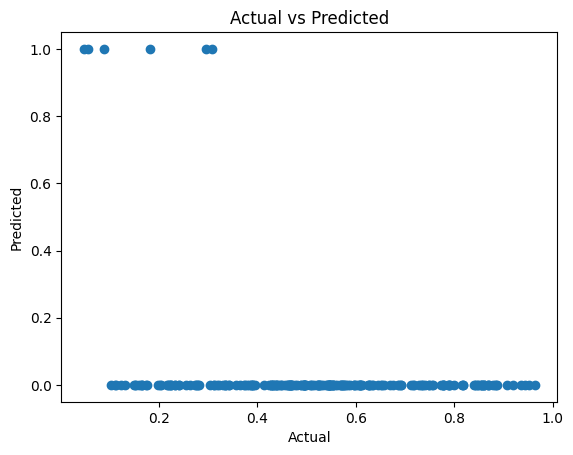

In [ ]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

-6.094433925816123

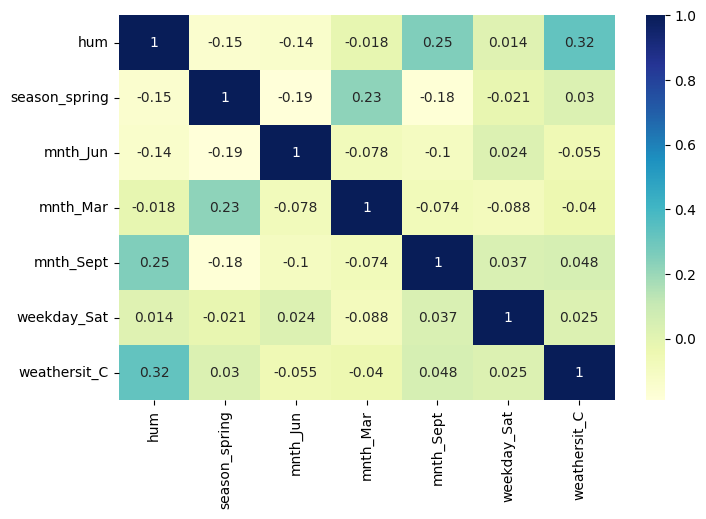

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(x_test[col2].corr(), cmap="YlGnBu", annot=True)
plt.show()